# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

#### Question 1
* 1.1) The intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters is to control model complexity by making the model reduce coefficient size and choose more predictive variables. This results in models being more reliable and easier to understand through enforcing a relationship where coefficients are "purchased" and proportionally "charged" in order to increase mean squared error.

* 1.2) Regularization provides a way of exploring the bias-variance trade-off through first lowering overall model variance by making coefficient values shrink towards 0. This shrinking of coefficient values and variance is accompanied by an increase in bias due to the model becoming simpler, so choosing an α value via cross validation that balances the model's variance and bias is important. The choosing of the α value is how bias-variance trade-off is explored.

* 1.3) LASSO regression shrinks coefficients to zero, removes variables from the model and selects a specific model, and has a penalty that has points of non-differentiability at 0. Ridge regression smoothly shrinks coefficients towards zero and does not remove any variables entirely. The answers change by LASSO producing an easier to understand model with less variables while Ridge provides a better performing and complete model with shrunken coefficients.

* 1.4) We typically scale variables for use in regularized regression by z-score normalizing the numeric variables. We do this because when comparing variables' explanatory power on the margin, their shifting scales can inaccurately enhance this comparison, causing inaccuracies in the interpretation of α and instability.

* 1.5) The α penalty is typically selected through K-Fold Cross Validation where the α value that minimizes the mean squared error or maximizes accuracy is chosen.

* 1.6) When conducting cross validation, you do not include the penalty term in evaluating the cross validated MSE because the penalty is only used in training the model and including it when evaluating the cross validated MSE would mix a training condition with MSE evaluation on test folds, resulting in an inaccurate MSE evaluation.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

       Unnamed: 0    Make_Year   Mileage_Run  Seating_Capacity         Price
count  976.000000   976.000000    976.000000        976.000000  9.760000e+02
mean   488.500000  2016.963115  41571.195697          5.095287  7.410195e+05
std    281.891232     2.818742  24390.995134          0.446224  3.673234e+05
min      1.000000  2011.000000   1117.000000          4.000000  1.880000e+05
25%    244.750000  2015.000000  22676.750000          5.000000  4.757500e+05
50%    488.500000  2017.000000  37570.500000          5.000000  6.665000e+05
75%    732.250000  2019.000000  57421.250000          5.000000  8.830000e+05
max    976.000000  2022.000000  99495.000000          8.000000  2.941000e+06
Intercept:  741019.4672131146  Coefficients:  [ 458071.11962682 -136698.07209968  -91643.12002369 -898405.75135637
  113603.82234772  -65144.89659918  229021.67655601  368955.71335914
  -84038.06614622]


C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.008e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.739e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

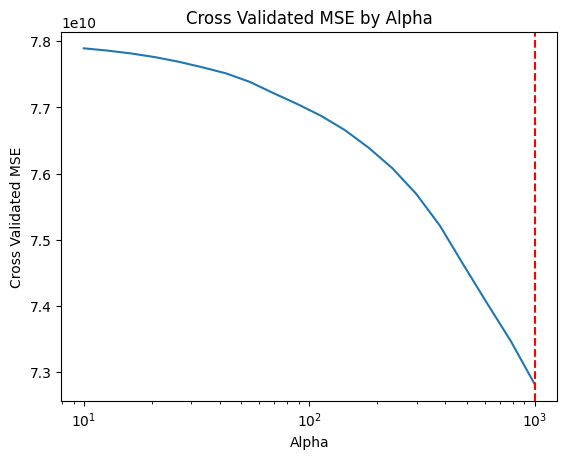

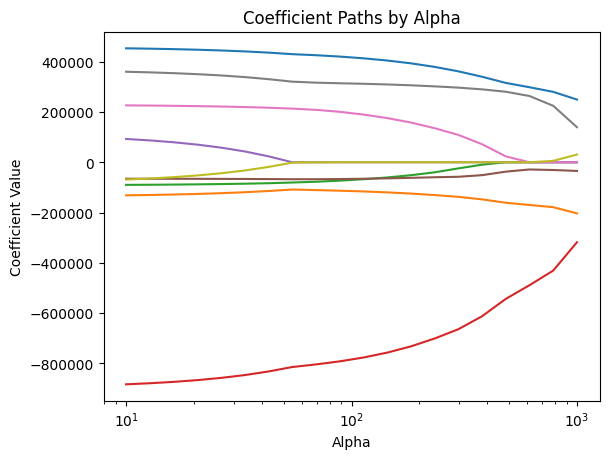

Features Selected:  ['Mileage_Run', 'Age', 'Mileage_Run Age', 'Mileage_Run^3', 'Mileage_Run Age^2', 'Age^3']
Proportion Set to Zero:  0.3333333333333333
Mileage_Run 458071.1196268243 279901.1444752475
Age -136698.0720996838 -178627.6494180889
Mileage_Run^2 -91643.12002368628 -0.0
Mileage_Run Age -898405.751356371 -430522.37116681226
Age^2 113603.82234772443 -0.0
Mileage_Run^3 -65144.89659917502 -30772.352392202363
Mileage_Run^2 Age 229021.67655600893 0.0
Mileage_Run Age^2 368955.7133591421 224381.02733896306
Age^3 -84038.06614621796 5666.626834897385


In [ ]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
import seaborn as sns
import matplotlib.pyplot as plt

#2.1)
carsData = pd.read_csv("./data/cars_hw.csv") 
print(carsData.describe())
carsData["Age"] = carsData["Make_Year"].max() - carsData["Make_Year"]
mileageAndAge = carsData[["Mileage_Run", "Age"]] 
expansion = PolynomialFeatures(degree = 3, include_bias = False)
fitExpansion = expansion.fit_transform(mileageAndAge)
scaler = StandardScaler()
scaleExpansion = scaler.fit_transform(fitExpansion)

#2.2
price = carsData["Price"]
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(scaleExpansion, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#2.3
alphas = np.logspace(1,3,20)
model = LassoCV(cv = 20, alphas = alphas, random_state = 100000000)
model.fit(scaleExpansion, price)
indexStar = np.argmin(np.median(model.mse_path_, axis = 1))
alphaStar = model.alphas_[indexStar]

#2.4
sns.lineplot(x = model.alphas_, y = np.median(model.mse_path_, axis = 1))
plt.axvline(x = alphaStar, color = 'red', linestyle = '--', linewidth = 1.5)
plt.xscale("log") 
plt.xlabel("Alpha") 
plt.ylabel("Cross Validated MSE")
plt.title("Cross Validated MSE by Alpha") 
plt.show()

#2.5
coefficients = []
for alpha in alphas:
    lassoModel = Lasso(alpha = alpha, max_iter=100000000, tol = 1e-4)
    lassoModel = lassoModel.fit(scaleExpansion, price)
    coefficients.append(lassoModel.coef_)
coefficients = np.array(coefficients)
for i in range(coefficients.shape[1]):
    plt.plot(alphas, coefficients[:, i])
plt.xscale("log") 
plt.xlabel("Alpha") 
plt.ylabel("Coefficient Value") 
plt.title("Coefficient Paths by Alpha")
plt.show()

#2.6
selectedFeatures = []
removedFeatures = []
features = expansion.get_feature_names_out(["Mileage_Run", "Age"])
coefficients = model.coef_
for i in range(len(coefficients)):
    if coefficients[i] != 0:
        selectedFeatures.append(features[i])
    else:
        removedFeatures.append(features[i])
print("Features Selected: ", selectedFeatures)
print("Proportion Set to Zero: ", len(removedFeatures)/ len(coefficients))

#2.7
linearRegressionCoefficients = regressionModel.coef_
optimallyRegularizedCoefficients = model.coef_
for i in range(len(features)):
    print(features[i], linearRegressionCoefficients[i], optimallyRegularizedCoefficients[i])



## Question 2
#### 2.2)
* The sign for the interaction between Mileage_Run and Age is negative.
#### 2.6)
* The Mileage_Run, Age, Mileage_Run Age, Mileage_Run^3, Mileage_Run Age^2, and Age^3 features were actually selected. The proportion set to zero is 33.3%.
#### 2.7)
* Only the Age coefficient increased in magnitude from linear regression to lasso while the remaining majority decrease. Age^2 and Mileage_Run^2 Age go from positive to 0 and Mileage_Run^2 goes from negative to 0. Age^3 is the only feature whose coefficient had a sign change, going from negative to positive.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.070e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.894e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or c

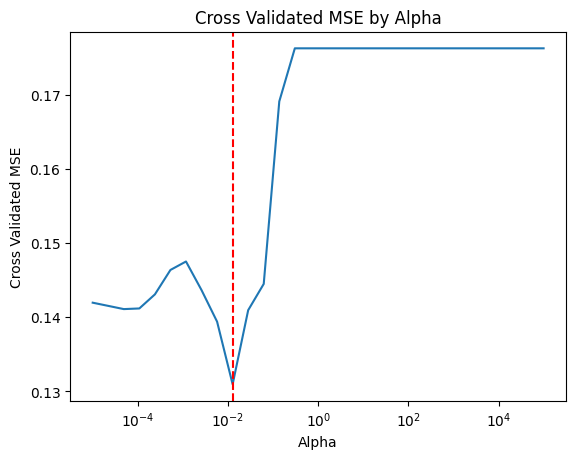

C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
C:\Users\jacka\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider in

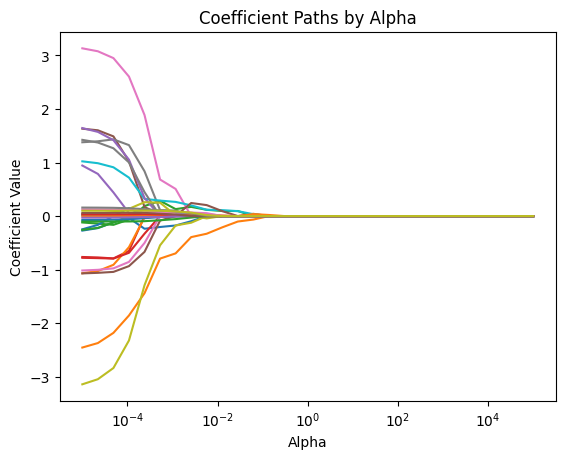

Features Selected:  ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']
Proportion Set to Zero:  0.5862068965517241
age 1.5391556093617114 -0.0
ejection_fraction -2.192493664234263 -0.329655882601242
serum_creatinine -0.8535881544613151 0.11687513008140925
age^2 -3.678653925325818 0.0
age ejection_fraction -0.6009180269804792 -0.0
age serum_creatinine 1.8415625716810449 0.0
ejection_fraction^2 3.430976464550497 0.0
ejection_fraction serum_creatinine 2.6733936217891374 0.0
serum_creatinine^2 -2.6470406100691304 -0.0
age^3 1.9931349422978752 0.11799179769122643
age^2 ejection_fraction 0.9080259541106153 0.0
age^2 serum_creatinine -0.6975215091977318 0.0
age ejection_fraction^2 -0.08120632445370864 0.0
age ejection_fraction serum_creatinine -1.5776652636623716 0.0
age serum_creat

In [12]:
import pandas as pd 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
import seaborn as sns 
import matplotlib.pyplot as plt

#3.1
heartFailureData = pd.read_csv("./data/heart_failure_clinical_records_dataset.csv")
print(heartFailureData.describe())
expansionFeatures = heartFailureData[["age", "ejection_fraction", "serum_creatinine"]] 
expansion = PolynomialFeatures(degree = 3, include_bias = False) 
fitExpansion = expansion.fit_transform(expansionFeatures)
scaler = StandardScaler() 
scaleExpansion = scaler.fit_transform(fitExpansion)
categoricalVariables = heartFailureData[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
categoricalExpansion = PolynomialFeatures(degree = 2, include_bias = False, interaction_only = True)
fitCategoricalExpansion = categoricalExpansion.fit_transform(categoricalVariables)
features = np.concatenate((scaleExpansion, fitCategoricalExpansion), axis = 1)

#3.2
deathEvent = heartFailureData["DEATH_EVENT"]
regressionModel = LinearRegression() 
regressionModel = regressionModel.fit(features, deathEvent)
expansionNames = expansion.get_feature_names_out(["age", "ejection_fraction", "serum_creatinine"]) 
categoricalExpansionNames = categoricalExpansion.get_feature_names_out(["anaemia", "diabetes", "high_blood_pressure", "smoking"]) 
totalFeatureNames = np.concatenate((expansionNames, categoricalExpansionNames))
for i in range(len(totalFeatureNames)):
    print(totalFeatureNames[i], regressionModel.coef_[i])
    
#3.3
alphas = np.logspace(-5, 5, 30) 
model = LassoCV(cv = 20, alphas = alphas, random_state = 100) 
model.fit(features, deathEvent) 
indexStar = np.argmin(np.median(model.mse_path_, axis = 1)) 
alphaStar = model.alphas_[indexStar]

#3.4
sns.lineplot(x = model.alphas_, y = np.median(model.mse_path_, axis = 1))
plt.axvline(x = alphaStar, color = 'red', linestyle = '--', linewidth = 1.5)
plt.xscale("log") 
plt.xlabel("Alpha") 
plt.ylabel("Cross Validated MSE")
plt.title("Cross Validated MSE by Alpha") 
plt.show()

#3.5
coefficients = []
for alpha in alphas:
    lassoModel = Lasso(alpha = alpha, max_iter=10_000)
    lassoModel = lassoModel.fit(features, deathEvent)
    coefficients.append(lassoModel.coef_)
coefficients = np.array(coefficients)
for i in range(coefficients.shape[1]):
    plt.plot(alphas, coefficients[:, i])
plt.xscale("log") 
plt.xlabel("Alpha") 
plt.ylabel("Coefficient Value") 
plt.title("Coefficient Paths by Alpha")
plt.show() 

#3.6
selectedFeatures = []
removedFeatures = []
coefficients = model.coef_
for i in range(len(coefficients)):
    if coefficients[i] != 0:
        selectedFeatures.append(totalFeatureNames[i])
    else:
        removedFeatures.append(totalFeatureNames[i])
print("Features Selected: ", selectedFeatures)
print("Proportion Set to Zero: ", len(removedFeatures)/ len(coefficients))
linearRegressionCoefficients = regressionModel.coef_
optimallyRegularizedCoefficients = model.coef_
for i in range(len(totalFeatureNames)):
    print(totalFeatureNames[i], linearRegressionCoefficients[i], optimallyRegularizedCoefficients[i])


## Question 3
#### 3.2)
* There are sign patterns that appear counterintuitive like age ejection_fraction being negative while age serum_creatinine is positive and ejection_fraction^3 being negative while ejection_fraction^2 is positive. These sign patterns happen because the numeric age, ejection_fraction, and serum_creatinine elements are transformed into multiple similar features which interact with the anaemia, diabetes, high_blood_pressure, and smoking elements and impact each other in various ways producing unexpected patterns. The multicolinearity produced from these transformed features interactions can result in counterintuitive sign patterns. I can see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction through allowing variables to be represented in multiple ways which allows for flexibility in coefficients.
#### 3.6)
* The ejection_fraction, serum_creatinine, age^3, ejection_fraction^3, ejection_fraction^2 serum_creatinine, serum_creatinine^3, anaemia, diabetes, high_blood_pressure, diabetes high_blood_pressure, diabetes smoking, and high_blood_pressure smoking features were actually selected. The proportion set equal to zero is 58.6%. Only the anaemia and high_blood_pressure coefficients increased in magnitude from linear regression to LASSO while the majority remaining decreased. high_blood_pressure, diabetes, serum_creatinine^3, ejection_fraction^2 serum_creatinine, ejection_fraction^3, and serum_creatinine had a sign change from linear regression to LASSO. The sign patterns for the LASSO seem to make more sense. This is because the linear regression has higher variance due to it not removing variables, while the LASSO has lower variance because it shrinks and sets coefficients to 0. This relates to bias-variance tradeoff because LASSO reduces variance at the cost of adding a small amount of bias.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

## Question 4
#### 4.1) 
$$ \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha b_1^2 $$
#### 4.2)
Derivative with respect to $b_0$:
$$ \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0 $$
$$ \sum (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) = 0 $$
$$ \sum \tilde{y}_i - nb_0 - b_1 \sum \tilde{x}_i = 0 $$
$$ 0- nb_0 - 0 = 0 $$
$$ b_0 = 0 $$
Derivative with respsect to $b_1$:
$$ -\frac{1}{n} \sum \tilde{x}_i (\tilde{y}_i - b_0 - b_1 \tilde{x}_i) + \alpha b_1 = 0 $$ $$ -\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i + \frac{b_1}{n} \sum \tilde{x}_i^2 + \alpha b_1 = 0 $$
$$ b_1(\frac{1}{n} \sum \tilde{x}_i^2 + \alpha) = \frac{1}{n} \sum \tilde{x}_i \tilde{y}_i $$
$$ b_1 = \frac{\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n} \sum \tilde{x}_i^2 + \alpha} $$
#### 4.3) 
* Increasing $\alpha$ changes the slope coefficient by making it shrink towards zero. 
#### 4.4) 
* If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, the challenge we run into is LASSO has points of non-differentiability at 0 called "corners", so using this penalty causes difficulty because of the lack of differentiability at these points. It is optimal to set $b_1 = 0$ when the penalty outweighs the effect of the features on the output.
